In [ ]:
'''
1. Matplotlib
2. Seaborn
3. Plotly

Analysis
----------
1. Bar Plot -> Stacked Bar chart, Column Chart
2. Pie Chart -> Donut Chart
3. Line Chart

Statistical Chart
-------------------
1. Correlation Heatmap -> Pearson, Spearman
2. Histograms
3. Box Plot
4. Violin Plot

Machine Learning
--------------
1. Scatter Plot
'''

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
# employee_name = ['Bob', 'Ram', 'Shyam', 'Jacob', 'John']
# salary = [10000, 40000, 27300, 33563, 45777]

company = {
    "employee_name": ['Bob', 'Ram', 'Shyam', 'Jacob', 'John'],
    "salary": [10000, 40000, 27300, 33563, 45777],
    "bonus": [5000, 10000, 13400, 12356, 20444]
}

In [3]:
def formatData(val):
    if val > 1e9:
        return f'{val / 1e9:,.2f}B'
    elif val > 1e6:
        return f'{val / 1e6:,.2f}M'
    elif val > 1e3:
        return f'{val / 1e3:,.2f}K'
    else:
        return f'{val}'

def plotData(dataframe, col_name, prefix='', ha_point='center', va_point='bottom'):
    for idx, val in enumerate(dataframe[col_name]):
        formatted_val = f'{prefix}'+formatData(val)
        plt.text(idx, val, formatted_val, ha=ha_point, va=va_point)

### Line Plot

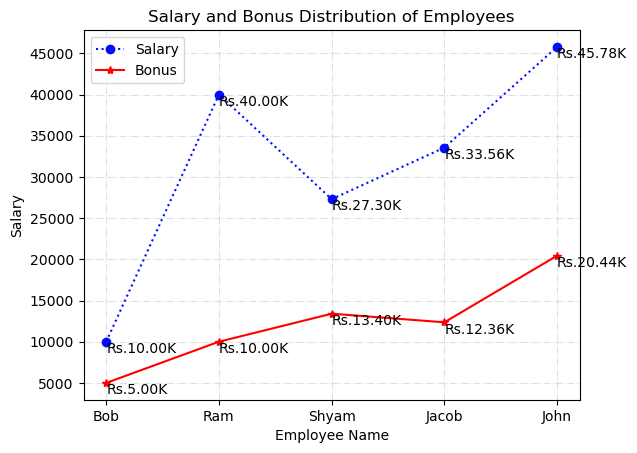

In [4]:
# salary
plt.plot(company['employee_name'], company['salary'], color='#000fff', marker='o', linestyle='dotted', label='Salary')

# bonus
plt.plot(company['employee_name'], company['bonus'], color='red', marker='*', label='Bonus')
plt.xlabel('Employee Name')
plt.ylabel('Salary')
plt.title('Salary and Bonus Distribution of Employees')
plt.grid(linestyle='dashdot', alpha=0.4)
plt.legend()

# show salary value in plot
# horizontal alignment (ha) = left, right, center
# vertical alignment (va) = top, bottom, center
plotData(company, 'salary', 'Rs.', 'left', 'top')
plotData(company, 'bonus', 'Rs.', 'left', 'top')

# code to save img
plt.savefig('salary_bonus.png')
plt.show()

### Bar Plot

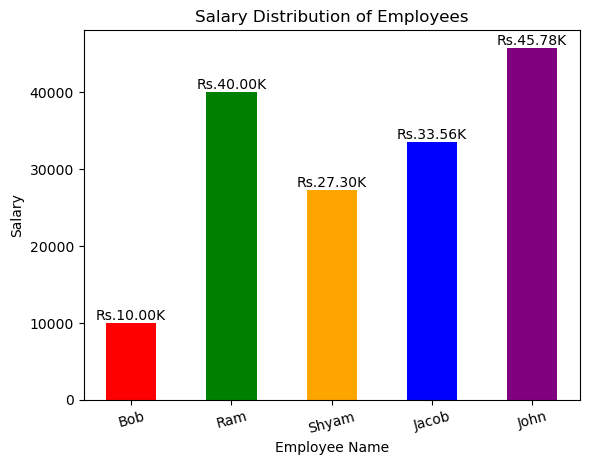

In [5]:
color_palette = ['red', 'green', 'orange', 'blue', 'purple']
plt.bar(company['employee_name'], company['salary'], color=color_palette, width=0.5)
plt.xlabel('Employee Name')
plt.ylabel('Salary')
plt.title('Salary Distribution of Employees')
plt.xticks(rotation=15)
plotData(company, 'salary', 'Rs.')
plt.show()

## Scatter Plot

In [6]:
# Only continuous data

In [7]:
df = pd.read_csv('Dataset/temperature.csv')
df.head()

,Temperature (°C),Humidity (%)
0,23.745401,57.186649
1,29.507143,66.765614
2,27.319939,64.034868
3,25.986585,60.921443
4,21.560186,49.099373


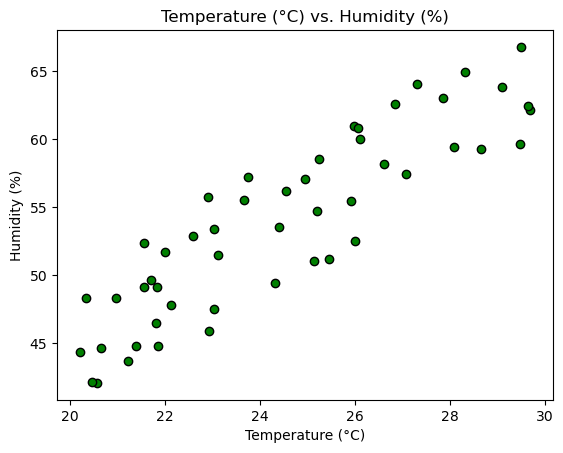

In [8]:
plt.scatter(df['Temperature (°C)'], df['Humidity (%)'], marker='o', color='green', edgecolor='black')
plt.xlabel('Temperature (°C)')
plt.ylabel('Humidity (%)')
plt.title('Temperature (°C) vs. Humidity (%)')
plt.show()

## HR Dataset

In [9]:
df = pd.read_csv('cleaned_hr.csv')
df.head()

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,Hire_Month_Name,Hire_Day_Name,Absence_Label,Absence_Id,Absence_Label_id,Col1,Col2,First_Name,Middle_Name,Last_Name
0,Adinolfi Wilson K,10026,0,0,1,1,5,4,0,62506,...,July,Tuesday,Low Absences,0,0,Low,Absences,Wilson,K,Adinolfi
1,Ait Sidi Karthikeyan,10084,1,1,1,5,3,3,0,104437,...,March,Monday,High Absences,2,2,High,Absences,Karthikeyan,NaN,Ait Sidi
2,Akinkuolie Sarah,10196,1,1,0,5,5,3,0,64955,...,July,Tuesday,Low Absences,0,0,Low,Absences,Sarah,NaN,Akinkuolie
3,AlagbeTrina,10088,1,1,0,1,5,3,0,64991,...,January,Monday,High Absences,2,2,High,Absences,Trina,NaN,Alagbe
4,Anderson Carol,10069,0,2,0,5,5,3,0,50825,...,July,Monday,Low Absences,0,0,Low,Absences,Carol,NaN,Anderson


### Pie Chart

In [10]:
perf_emp = df.groupby('PerformanceScore')['EmpID'].count().reset_index()
perf_emp

,PerformanceScore,EmpID
0,Exceeds,37
1,Fully Meets,243
2,Needs Improvement,18
3,PIP,13


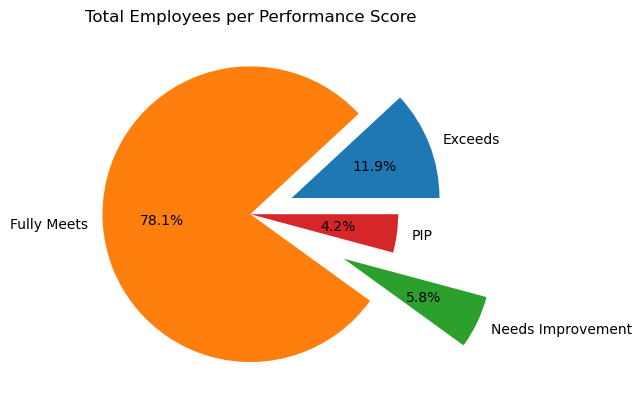

In [11]:
plt.pie(
    perf_emp['EmpID'],
    labels=perf_emp['PerformanceScore'],
    autopct='%1.1f%%',
    explode=(0.3, 0, 0.7, 0)
)
plt.title('Total Employees per Performance Score')
plt.show()

### Donut Chart

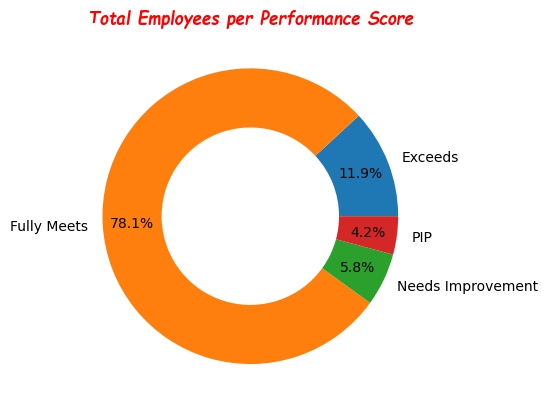

In [12]:
plt.pie(
    perf_emp['EmpID'],
    labels=perf_emp['PerformanceScore'],
    autopct='%1.1f%%',
    # width edge properties
    wedgeprops = {'width': 0.4},
    # percentage distance
    pctdistance=0.8,
    textprops={'color':'black'}
)
plt.title('Total Employees per Performance Score', fontsize='large', color='red', fontweight='bold',
         fontfamily='cursive', fontstyle='oblique')
plt.show()

### Column Chart

In [13]:
# Find total salary distribution of performance score by gender.
perf_gen = df.groupby(['PerformanceScore', 'Gender'])['Salary'].sum().reset_index()
perf_gen

,PerformanceScore,Gender,Salary
0,Exceeds,F,1415570
1,Exceeds,M,1438790
2,Fully Meets,F,9664438
3,Fully Meets,M,6948675
4,Needs Improvement,F,569170
5,Needs Improvement,M,662166
6,PIP,F,281286
7,PIP,M,485338


In [14]:
# def plotData(dataframe, col_name, prefix='', ha_point='center', va_point='bottom'):
#     for idx, val in enumerate(dataframe[col_name]):
#         formatted_val = f'{prefix}'+formatData(val)
#         plt.text(idx, val, formatted_val, ha=ha_point, va=va_point)

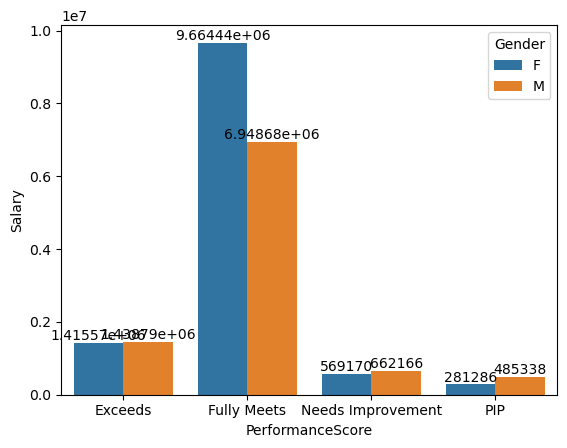

In [15]:
ax = sns.barplot(data=perf_gen, x='PerformanceScore', y='Salary', hue='Gender')

for container in ax.containers:
    plt.bar_label(container)

## Statistical Charts

### Correlation Heatmap

In [16]:
'''
1. Pearson -> Linear Relationship
2. Spearman -> Non-Linear Relationship
'''

'\n1. Pearson -> Linear Relationship\n2. Spearman -> Non-Linear Relationship\n'

In [17]:
data = df.select_dtypes(['int', 'float'])
data = data.drop(columns = ['EmpID', 'MarriedID', 'MaritalStatusID', 'GenderID',
                           'EmpStatusID', 'FromDiversityJobFairID', 'Zip',
                           'Hire_Year', 'Hire_Month', 'Hire_Day', 'Absence_Id', 'Absence_Label_id'])

In [18]:
corr_data = data.corr(method='pearson')
# corr_data

<Axes: >

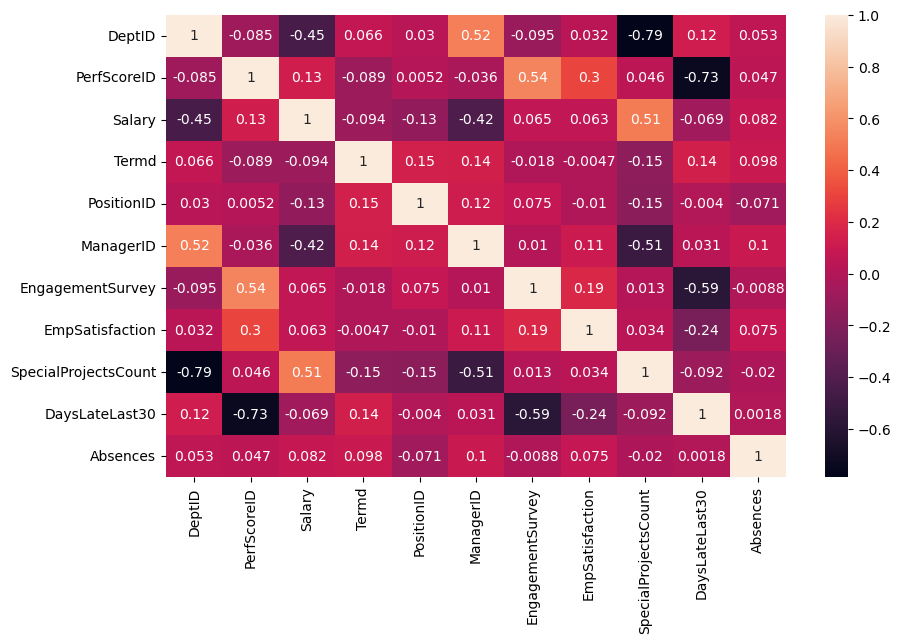

In [19]:
plt.figure(figsize=(10, 6))
sns.heatmap(corr_data, annot=True)

## Histogram

In [72]:
filter_salary = df[df['Salary'] < 80000]

In [73]:
filter_salary['Salary'].skew()

np.float64(0.048420831309714654)

In [77]:
filter_salary.shape

(253, 49)

In [74]:
plt.figure(figsize=(6, 4))
plt.hist(df['Salary'], edgecolor='black')
plt.close()

In [75]:
# KDE (Kernel Density Estimator) lines
# Mean Median lines
mean_salary = filter_salary['Salary'].mean()
median_salary = filter_salary['Salary'].median()

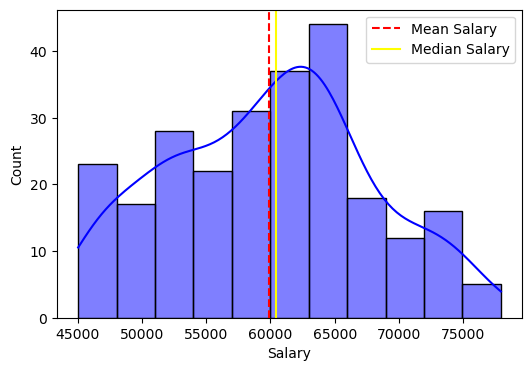

In [76]:
plt.figure(figsize=(6, 4))
sns.histplot(filter_salary['Salary'], kde=True, bins=11, color='blue')
# axvline (axis vertical lines)
plt.axvline(mean_salary, color='red', linestyle='dashed', label='Mean Salary')
plt.axvline(median_salary, color='yellow', label='Median Salary')
plt.legend()
plt.show()

### Box Plot

In [ ]:
'''
- circle -> outliers
- T-Shape -> Wishkers
'''

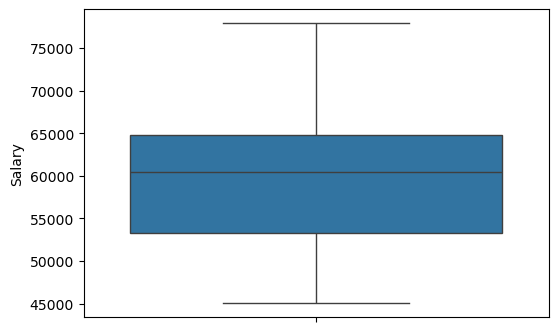

In [78]:
plt.figure(figsize=(6, 4))
sns.boxplot(filter_salary['Salary'])
plt.show()

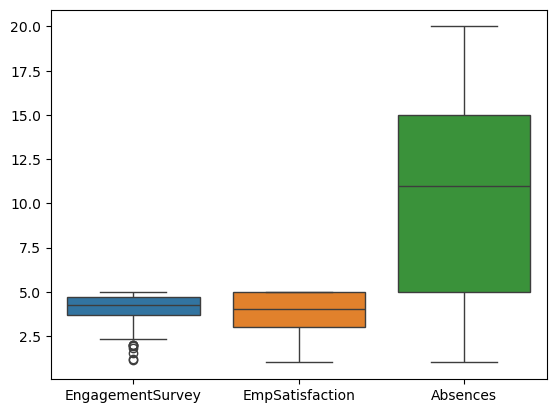

In [80]:
sns.boxplot(filter_salary[['EngagementSurvey', 'EmpSatisfaction', 'Absences']])
plt.show()

### Violin Plot

In [81]:
import plotly.express as px

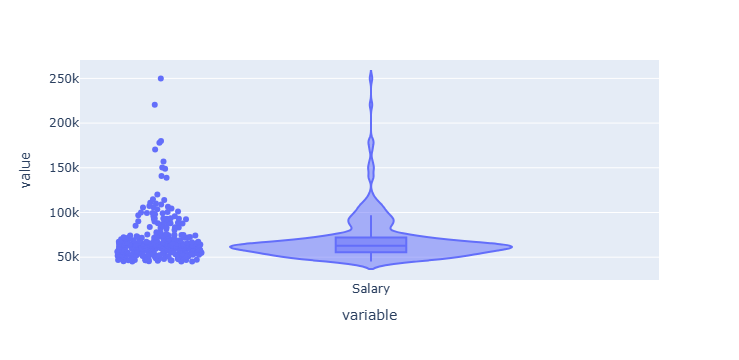

In [91]:
fig = px.violin(
    df,
    y=['Salary'],
    box=True,
    points='all'
)
fig.show()

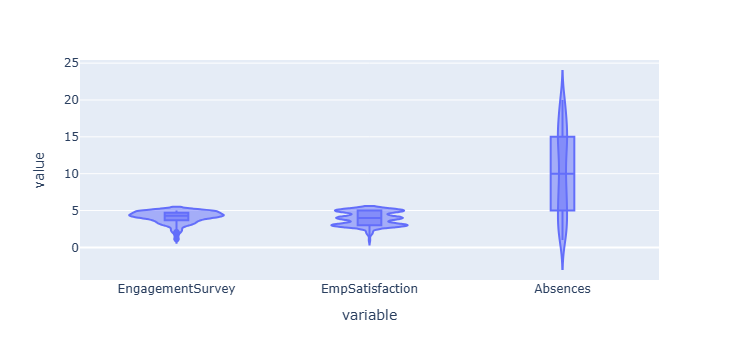

In [93]:
fig = px.violin(
    df,
    y=['EngagementSurvey', 'EmpSatisfaction', 'Absences'],
    box=True
)
fig.show()